# 10-Model Hyperparameter Ensemble vs Single Best Model

Takes the **top 10 configurations** from `XGB_tuning3` and trains each with the same walk-forward CV protocol (no bootstrap â€” diversity comes purely from hyperparameter variation). The ensemble prediction is the **mean** of the 10 member predictions.

**Comparison baseline:** the single stability-chosen model from `forecasting_results.ipynb` (rank #6: d=6, mcw=3, g=1.0, cbt=0.6, rl=1.0, lr=0.02).

**Additional analysis:** ensemble prediction range (max - min across members) and its relationship to prediction accuracy.

## Section 1 â€” Setup

In [24]:

from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt


%matplotlib inline

PROJECT_ROOT = Path("..").resolve()
GOLD_DIR     = PROJECT_ROOT / "data" / "gold" / "stage1" / "hM7_Linj14_tau150_hT7"
OUT_DIR      = PROJECT_ROOT / "data" / "ensemble_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Gold dir:     {GOLD_DIR}")

Project root: C:\Users\arius\Desktop\kalshi_wnba_bot
Gold dir:     C:\Users\arius\Desktop\kalshi_wnba_bot\data\gold\stage1\hM7_Linj14_tau150_hT7


In [25]:
# --- Top 10 configurations from XGB_tuning3 (sorted by mean_ll ascending) ---
# All share: objective=binary:logistic, eval_metric=logloss, subsample=0.8, reg_alpha=0.0, seed=42
FIXED_PARAMS = {
    "objective":   "binary:logistic",
    "eval_metric": "logloss",
    "subsample":   0.8,
    "reg_alpha":   0.0,
    "seed":        42,
    "nthread":    -1,
}

TOP_10_CONFIGS = [
    {"max_depth": 6, "min_child_weight": 3, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.03},  # rank 1, 0.59749
    {"max_depth": 6, "min_child_weight": 3, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.02},  # rank 2, 0.59787
    {"max_depth": 6, "min_child_weight": 3, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 0.5, "learning_rate": 0.01},  # rank 3, 0.59813
    {"max_depth": 8, "min_child_weight": 3, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.02},  # rank 4, 0.59815
    {"max_depth": 7, "min_child_weight": 3, "gamma": 0.5, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.02},  # rank 5, 0.59820
    {"max_depth": 6, "min_child_weight": 3, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.02},  # rank 2, 0.59787 (single-model pick)
    {"max_depth": 8, "min_child_weight": 3, "gamma": 0.0, "colsample_bytree": 0.6, "reg_lambda": 2.0, "learning_rate": 0.02},  # rank 7, 0.59839
    {"max_depth": 6, "min_child_weight": 3, "gamma": 0.0, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.02},  # rank 8, 0.59841
    {"max_depth": 6, "min_child_weight": 2, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 0.5, "learning_rate": 0.03},  # rank 9, 0.59844
    {"max_depth": 6, "min_child_weight": 2, "gamma": 0.1, "colsample_bytree": 0.6, "reg_lambda": 1.0, "learning_rate": 0.03},  # rank 10, 0.59860
]

# The single-model baseline (stability pick = rank 2)
SINGLE_MODEL_CONFIG = TOP_10_CONFIGS[5]

NUM_BOOST_ROUND       = 3000
EARLY_STOPPING_ROUNDS = 150
N_PLAYERS             = 7
CLIP_EPS              = 1e-6
LABEL_COL             = "home_win"
OOF_YEARS             = list(range(2020, 2025))
TRAIN_START           = 2015

print(f"Ensemble members: {len(TOP_10_CONFIGS)}")
print(f"Single-model baseline: {SINGLE_MODEL_CONFIG}")

Ensemble members: 10
Single-model baseline: {'max_depth': 6, 'min_child_weight': 3, 'gamma': 1.0, 'colsample_bytree': 0.6, 'reg_lambda': 1.0, 'learning_rate': 0.02}


In [26]:
# --- Feature columns & data loading (same as XGB_tuning3 / forecasting_results) ---
PLAYER_MODEL_FEATURES = [
    "m_ewma_pre", "q_pre", "days_since_first_report_pre",
    "days_since_last_dnp_pre", "consec_dnps_pre", "played_last_game_pre",
    "minutes_last_game_pre", "days_since_last_played_pre",
    "injury_present_flag_pre",
]
RECENT_FORM_FEATURES = ["net_rtg_ewma_pre", "efg_ewma_pre", "tov_pct_ewma_pre", "orb_pct_ewma_pre", "ftr_ewma_pre"]
STYLE_FEATURES = ["off_3pa_rate_pre", "def_3pa_allowed_pre", "off_2pa_rate_pre", "def_2pa_allowed_pre", "off_tov_pct_pre", "def_forced_tov_pre"]
SCHEDULE_FEATURES = ["days_rest_pre", "is_b2b_pre", "games_last_4_days_pre", "games_last_7_days_pre", "travel_miles_pre", "timezone_shift_hours_pre"]

def build_feature_cols(n_players):
    cols = []
    for side in ("home", "away"):
        for slot in range(1, n_players + 1):
            for feat in PLAYER_MODEL_FEATURES:
                cols.append(f"{side}_p{slot}_{feat}")
    for feat in RECENT_FORM_FEATURES + STYLE_FEATURES + SCHEDULE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    return cols

FEATURE_COLS = build_feature_cols(N_PLAYERS)

def load_gold(season):
    p = GOLD_DIR / f"game_xgboost_input_{season}_REGPST.csv"
    df = pd.read_csv(p)
    df["season"] = df["season"].astype(int)
    cold = (df["home_p1_m_ewma_pre"] == 0) | (df["away_p1_m_ewma_pre"] == 0)
    n_drop = cold.sum()
    if n_drop:
        df = df[~cold].reset_index(drop=True)
        print(f"  [load {season}] dropped {n_drop} cold-start rows")
    return df

def load_range(start, end):
    dfs = [load_gold(y) for y in range(start, end + 1)]
    return pd.concat(dfs, ignore_index=True).dropna(subset=["home_win", "base_margin"])

def clip(p):
    return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def compute_metrics(y, p):
    p = clip(p)
    return {
        "log_loss":  log_loss(y, p),
        "brier":     brier_score_loss(y, p),
        "accuracy":  accuracy_score(y, (p >= 0.5).astype(int)),
        "n_games":   len(y),
    }

print(f"Feature columns: {len(FEATURE_COLS)}")

Feature columns: 160


In [27]:
# --- XGBoost train helper (same nested ES protocol) ---
def make_dmatrix(X, y, bm, feature_names):
    dm = xgb.DMatrix(X.astype(float), label=y.astype(float),
                     feature_names=feature_names, missing=np.nan)
    dm.set_base_margin(bm.astype(float))
    return dm

def train_xgb_config(config, X_es_train, y_es_train, bm_es_train,
                      X_es_val, y_es_val, bm_es_val,
                      X_test, bm_test, feature_names):
    """Nested early stopping: find best_round on es_val, retrain on full train, predict test."""
    params = {**FIXED_PARAMS, **config}

    dm_es_train = make_dmatrix(X_es_train, y_es_train, bm_es_train, feature_names)
    dm_es_val   = make_dmatrix(X_es_val, y_es_val, bm_es_val, feature_names)

    es_model = xgb.train(
        params, dm_es_train, NUM_BOOST_ROUND,
        evals=[(dm_es_val, "val")],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )
    best_round = es_model.best_iteration + 1

    # Retrain on es_train + es_val combined
    X_full  = np.vstack([X_es_train, X_es_val])
    y_full  = np.concatenate([y_es_train, y_es_val])
    bm_full = np.concatenate([bm_es_train, bm_es_val])
    dm_full = make_dmatrix(X_full, y_full, bm_full, feature_names)
    dm_test = make_dmatrix(X_test, np.zeros(len(X_test)), bm_test, feature_names)

    model = xgb.train(params, dm_full, num_boost_round=best_round, verbose_eval=False)
    preds = clip(model.predict(dm_test))
    return preds, best_round

print("Training helper ready.")

Training helper ready.


## Section 2 â€” Walk-Forward OOF (2020â€“2024): Single Model + 10-Member Ensemble

For each test year Y:
- ES-train on 2015..Y-2, ES-val on Y-1 to find best_round
- Retrain on 2015..Y-1, predict on Y
- Repeat for all 10 configs + collect per-game member predictions

In [28]:
oof_records = []  # per-game: game_id, season, home_win, single_pred, ensemble_pred, member preds, range

for test_year in OOF_YEARS:
    print(f"\n--- Fold: test_year = {test_year} ---")
    es_val_year = test_year - 1

    es_train_df = load_range(TRAIN_START, es_val_year - 1)
    es_val_df   = load_gold(es_val_year).dropna(subset=["home_win", "base_margin"])
    test_df     = load_gold(test_year).dropna(subset=["home_win", "base_margin"])

    avail = [c for c in FEATURE_COLS if c in es_train_df.columns]

    X_es_train  = es_train_df[avail].values
    X_es_val    = es_val_df[avail].values
    X_test      = test_df[avail].values
    y_es_train  = es_train_df["home_win"].values.astype(float)
    y_es_val    = es_val_df["home_win"].values.astype(float)
    y_test      = test_df["home_win"].values.astype(float)
    bm_es_train = es_train_df["base_margin"].values.astype(float)
    bm_es_val   = es_val_df["base_margin"].values.astype(float)
    bm_test     = test_df["base_margin"].values.astype(float)

    # Train all 10 members
    member_preds = []
    for i, config in enumerate(TOP_10_CONFIGS):
        preds, br = train_xgb_config(
            config, X_es_train, y_es_train, bm_es_train,
            X_es_val, y_es_val, bm_es_val,
            X_test, bm_test, avail
        )
        member_preds.append(preds)
        if i == 5:  # single-model baseline (rank 2)
            single_preds = preds.copy()
            print(f"  single model (rank 2) best_round={br}")

    member_preds = np.array(member_preds)  # shape: (10, n_test_games)
    ensemble_pred = member_preds.mean(axis=0)
    pred_range    = member_preds.max(axis=0) - member_preds.min(axis=0)

    # Collect per-game records
    for j in range(len(test_df)):
        rec = {
            "game_id":        test_df.iloc[j]["game_id"],
            "season":         int(test_df.iloc[j]["season"]),
            "home_win":       int(y_test[j]),
            "single_pred":    float(single_preds[j]),
            "ensemble_pred":  float(ensemble_pred[j]),
            "pred_range":     float(pred_range[j]),
        }
        for k in range(10):
            rec[f"member_{k+1}_pred"] = float(member_preds[k, j])
        oof_records.append(rec)

    # Print fold metrics
    m_single = compute_metrics(y_test, single_preds)
    m_ens    = compute_metrics(y_test, ensemble_pred)
    print(f"  Single:   LL={m_single['log_loss']:.5f}  Brier={m_single['brier']:.5f}  Acc={m_single['accuracy']:.3f}")
    print(f"  Ensemble: LL={m_ens['log_loss']:.5f}  Brier={m_ens['brier']:.5f}  Acc={m_ens['accuracy']:.3f}")
    print(f"  Mean pred range: {pred_range.mean():.4f}  Max: {pred_range.max():.4f}")

oof_df = pd.DataFrame(oof_records)
oof_df.to_csv(OUT_DIR / "oof_ensemble_comparison.csv", index=False)
print(f"\nSaved: oof_ensemble_comparison.csv ({len(oof_df)} rows)")


--- Fold: test_year = 2020 ---
  [load 2015] dropped 7 cold-start rows
  single model (rank 2) best_round=10
  Single:   LL=0.59452  Brier=0.20236  Acc=0.714
  Ensemble: LL=0.59346  Brier=0.20214  Acc=0.701
  Mean pred range: 0.0622  Max: 0.1564

--- Fold: test_year = 2021 ---
  [load 2015] dropped 7 cold-start rows
  single model (rank 2) best_round=67
  Single:   LL=0.60533  Brier=0.21059  Acc=0.656
  Ensemble: LL=0.60474  Brier=0.21055  Acc=0.656
  Mean pred range: 0.0804  Max: 0.1886

--- Fold: test_year = 2022 ---
  [load 2015] dropped 7 cold-start rows
  single model (rank 2) best_round=13
  Single:   LL=0.61196  Brier=0.21253  Acc=0.653
  Ensemble: LL=0.61288  Brier=0.21299  Acc=0.661
  Mean pred range: 0.0786  Max: 0.2247

--- Fold: test_year = 2023 ---
  [load 2015] dropped 7 cold-start rows
  single model (rank 2) best_round=44
  Single:   LL=0.59529  Brier=0.20338  Acc=0.696
  Ensemble: LL=0.59675  Brier=0.20453  Acc=0.704
  Mean pred range: 0.0451  Max: 0.1161

--- Fold: t

### Table 1 â€” OOF Pooled: Single Model vs Ensemble

In [29]:
y_oof = oof_df["home_win"].values
rows = []
for name, col in [("Single (rank 2)", "single_pred"), ("Ensemble (top 10 mean)", "ensemble_pred")]:
    m = compute_metrics(y_oof, oof_df[col].values)
    m["model"] = name
    rows.append(m)

oof_summary = pd.DataFrame(rows)[["model", "log_loss", "brier", "accuracy", "n_games"]]
oof_summary

,model,log_loss,brier,accuracy,n_games
0,Single (rank 2),0.598917,0.205251,0.684870,1117
1,Ensemble (top 10 mean),0.599252,0.205621,0.690242,1117


### Table 2 â€” OOF Per-Fold Breakdown

In [30]:
fold_rows = []
for year in OOF_YEARS:
    sub = oof_df[oof_df["season"] == year]
    y = sub["home_win"].values
    for name, col in [("Single", "single_pred"), ("Ensemble", "ensemble_pred")]:
        m = compute_metrics(y, sub[col].values)
        m["fold_year"] = year
        m["model"] = name
        m["mean_range"] = sub["pred_range"].mean()
        fold_rows.append(m)

fold_table = pd.DataFrame(fold_rows)[["fold_year", "model", "log_loss", "brier", "accuracy", "mean_range", "n_games"]]
fold_table

,fold_year,model,log_loss,brier,accuracy,mean_range,n_games
0,2020,Single,0.594516,0.202357,0.714286,0.062212,147
1,2020,Ensemble,0.593457,0.202140,0.700680,0.062212,147
2,2021,Single,0.605332,0.210586,0.655502,0.080446,209
3,2021,Ensemble,0.604744,0.210548,0.655502,0.080446,209
4,2022,Single,0.611963,0.212530,0.652720,0.078609,239
5,2022,Ensemble,0.612878,0.212987,0.661088,0.078609,239
6,2023,Single,0.595291,0.203378,0.696154,0.045094,260
7,2023,Ensemble,0.596747,0.204532,0.703846,0.045094,260
8,2024,Single,0.587965,0.197838,0.709924,0.064248,262
9,2024,Ensemble,0.588179,0.198005,0.725191,0.064248,262


## Section 3 — 2025 Holdout: Single Model vs Ensemble

> **Note:** This section runs the final once-only evaluation on the 2025 holdout season.
> Results are reported here for completeness **only**.
> All analytical sections (range analysis, std dev analysis, policy-relevant conclusions)
> use **OOF 2020–2024 only** and do not touch 2025 data.

In [31]:
# For holdout: ES-train on 2015-2023, ES-val on 2024, predict 2025
es_train_h_df = load_range(TRAIN_START, 2023)
es_val_h_df   = load_gold(2024).dropna(subset=["home_win", "base_margin"])
holdout_df    = load_gold(2025).dropna(subset=["home_win", "base_margin"])

avail = [c for c in FEATURE_COLS if c in es_train_h_df.columns]

X_es_tr_h  = es_train_h_df[avail].values
y_es_tr_h  = es_train_h_df["home_win"].values.astype(float)
bm_es_tr_h = es_train_h_df["base_margin"].values.astype(float)
X_es_val_h = es_val_h_df[avail].values
y_es_val_h = es_val_h_df["home_win"].values.astype(float)
bm_es_val_h = es_val_h_df["base_margin"].values.astype(float)
X_holdout   = holdout_df[avail].values
y_holdout   = holdout_df["home_win"].values.astype(float)
bm_holdout  = holdout_df["base_margin"].values.astype(float)

holdout_member_preds = []
for i, config in enumerate(TOP_10_CONFIGS):
    preds, br = train_xgb_config(
        config, X_es_tr_h, y_es_tr_h, bm_es_tr_h,
        X_es_val_h, y_es_val_h, bm_es_val_h,
        X_holdout, bm_holdout, avail
    )
    holdout_member_preds.append(preds)
    if i == 5:
        holdout_single = preds.copy()
        print(f"Single model (rank 2) holdout best_round={br}")

holdout_member_preds = np.array(holdout_member_preds)
holdout_ensemble = holdout_member_preds.mean(axis=0)
holdout_range    = holdout_member_preds.max(axis=0) - holdout_member_preds.min(axis=0)

# Save holdout predictions
holdout_records = []
for j in range(len(holdout_df)):
    rec = {
        "game_id":       holdout_df.iloc[j]["game_id"],
        "season":        2025,
        "home_win":      int(y_holdout[j]),
        "single_pred":   float(holdout_single[j]),
        "ensemble_pred": float(holdout_ensemble[j]),
        "pred_range":    float(holdout_range[j]),
    }
    for k in range(10):
        rec[f"member_{k+1}_pred"] = float(holdout_member_preds[k, j])
    holdout_records.append(rec)

holdout_pred_df = pd.DataFrame(holdout_records)
holdout_pred_df.to_csv(OUT_DIR / "holdout_ensemble_comparison.csv", index=False)

m_s = compute_metrics(y_holdout, holdout_single)
m_e = compute_metrics(y_holdout, holdout_ensemble)
print(f"\nHoldout Single:   LL={m_s['log_loss']:.5f}  Brier={m_s['brier']:.5f}  Acc={m_s['accuracy']:.3f}")
print(f"Holdout Ensemble: LL={m_e['log_loss']:.5f}  Brier={m_e['brier']:.5f}  Acc={m_e['accuracy']:.3f}")
print(f"Mean holdout pred range: {holdout_range.mean():.4f}")

  [load 2015] dropped 7 cold-start rows
Single model (rank 2) holdout best_round=83

Holdout Single:   LL=0.61505  Brier=0.21255  Acc=0.665
Holdout Ensemble: LL=0.61628  Brier=0.21282  Acc=0.658
Mean holdout pred range: 0.0840


### Table 3 â€” Holdout Summary

In [32]:
holdout_rows = []
for name, preds in [("Single (rank 2)", holdout_single), ("Ensemble (top 10 mean)", holdout_ensemble)]:
    m = compute_metrics(y_holdout, preds)
    m["model"] = name
    m["mean_range"] = holdout_range.mean()
    holdout_rows.append(m)

holdout_summary = pd.DataFrame(holdout_rows)[["model", "log_loss", "brier", "accuracy", "mean_range", "n_games"]]
holdout_summary

,model,log_loss,brier,accuracy,mean_range,n_games
0,Single (rank 2),0.61505,0.212554,0.664516,0.08401,310
1,Ensemble (top 10 mean),0.61628,0.212822,0.658065,0.08401,310


## Section 4 — Ensemble Prediction Range Analysis (OOF 2020–2024)

**Prediction range** = max(member predictions) − min(member predictions) per game.

All analysis in this section uses **OOF predictions only** to avoid look-ahead bias.
The 2025 holdout is not touched here.

In [33]:
# Restrict all downstream analysis to OOF (no look-ahead into 2025)
all_df = oof_df.copy()
all_df["correct"] = ((all_df["ensemble_pred"] >= 0.5).astype(int) == all_df["home_win"]).astype(int)
all_df["single_correct"] = ((all_df["single_pred"] >= 0.5).astype(int) == all_df["home_win"]).astype(int)
all_df["abs_edge"] = (all_df["ensemble_pred"] - 0.5).abs()

print(f"Analysis dataset: {len(all_df)} OOF games (2020–2024 only)")
print(f"\nPrediction range stats (OOF):")
print(all_df["pred_range"].describe().round(4))


Analysis dataset: 1117 OOF games (2020–2024 only)

Prediction range stats (OOF):
count    1117.0000
mean        0.0656
std         0.0335
min         0.0086
25%         0.0405
50%         0.0601
75%         0.0837
max         0.2247
Name: pred_range, dtype: float64


### Graph 1 â€” Distribution of Ensemble Prediction Range

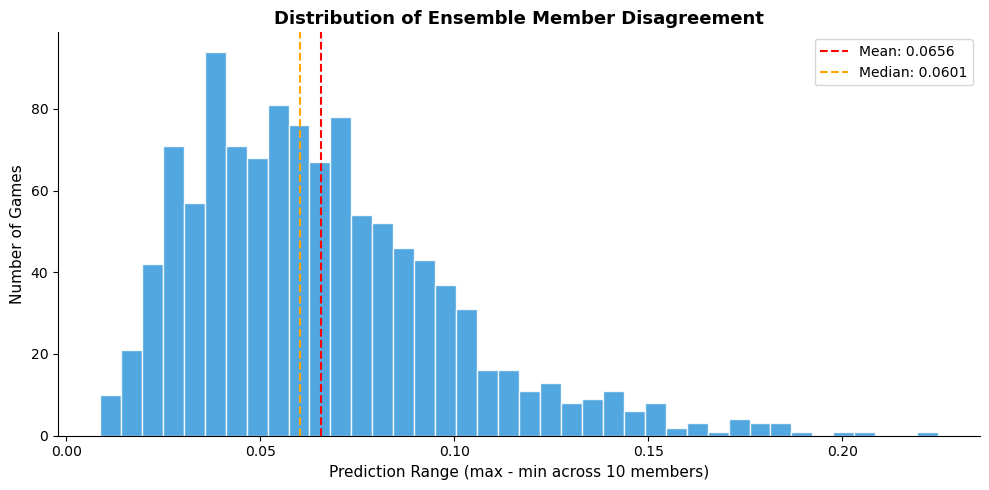

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_df["pred_range"], bins=40, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(all_df["pred_range"].mean(), color="red", linestyle="--", label=f'Mean: {all_df["pred_range"].mean():.4f}')
ax.axvline(all_df["pred_range"].median(), color="orange", linestyle="--", label=f'Median: {all_df["pred_range"].median():.4f}')
ax.set_xlabel("Prediction Range (max - min across 10 members)", fontsize=11)
ax.set_ylabel("Number of Games", fontsize=11)
ax.set_title("Distribution of Ensemble Member Disagreement", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "pred_range_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 2 â€” Accuracy by Prediction Range Quintile

Bins games into quintiles by prediction range and compares ensemble accuracy in each bin.

 quintile  n_games  range_lo  range_hi  mean_range  ens_accuracy  single_accuracy  ens_log_loss  single_log_loss  ens_brier
        1      224    0.0086    0.0369      0.0273        0.7545           0.7589        0.5383           0.5381     0.1757
        2      223    0.0371    0.0527      0.0445        0.7309           0.7220        0.5572           0.5572     0.1885
        3      223    0.0527    0.0687      0.0605        0.6816           0.6592        0.6128           0.6151     0.2118
        4      223    0.0687    0.0907      0.0783        0.6278           0.6368        0.6507           0.6509     0.2293
        5      224    0.0907    0.2247      0.1175        0.6562           0.6473        0.6372           0.6334     0.2229


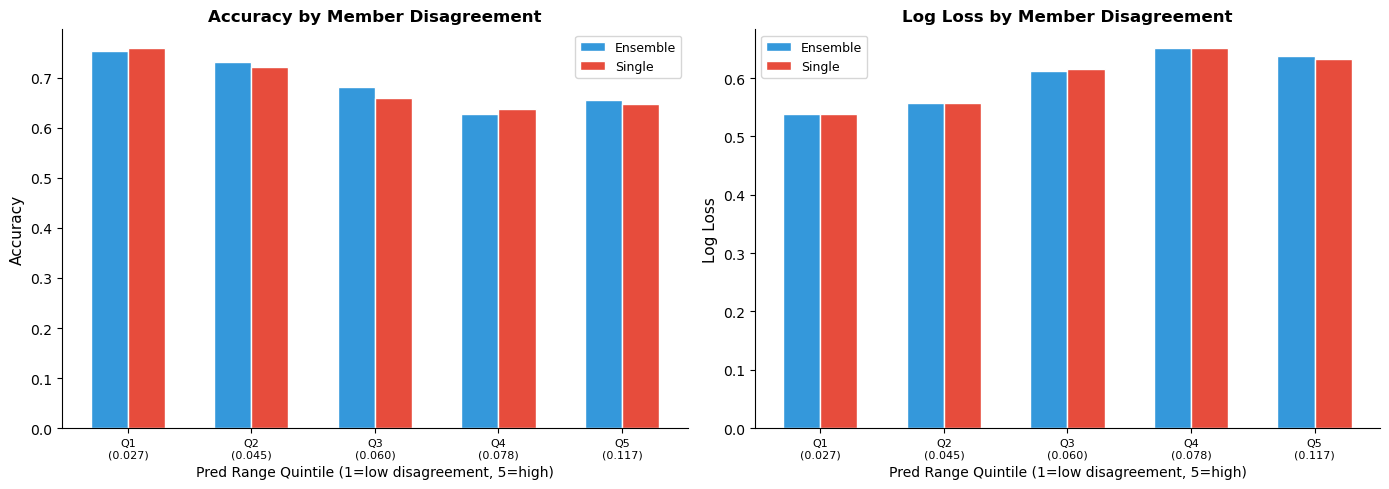

In [35]:
all_df["range_quintile"] = pd.qcut(all_df["pred_range"], q=5, labels=False, duplicates="drop") + 1

quintile_stats = []
for q in sorted(all_df["range_quintile"].unique()):
    sub = all_df[all_df["range_quintile"] == q]
    y = sub["home_win"].values
    quintile_stats.append({
        "quintile": q,
        "n_games": len(sub),
        "range_lo": sub["pred_range"].min(),
        "range_hi": sub["pred_range"].max(),
        "mean_range": sub["pred_range"].mean(),
        "ens_accuracy": sub["correct"].mean(),
        "single_accuracy": sub["single_correct"].mean(),
        "ens_log_loss": log_loss(y, clip(sub["ensemble_pred"].values)),
        "single_log_loss": log_loss(y, clip(sub["single_pred"].values)),
        "ens_brier": brier_score_loss(y, clip(sub["ensemble_pred"].values)),
    })

q_df = pd.DataFrame(quintile_stats)
print(q_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by quintile
ax = axes[0]
x = q_df["quintile"]
ax.bar(x - 0.15, q_df["ens_accuracy"], width=0.3, color="#3498db", label="Ensemble", edgecolor="white")
ax.bar(x + 0.15, q_df["single_accuracy"], width=0.3, color="#e74c3c", label="Single", edgecolor="white")
ax.set_xlabel("Pred Range Quintile (1=low disagreement, 5=high)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy by Member Disagreement", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Q{int(q)}\n({r:.3f})" for q, r in zip(q_df["quintile"], q_df["mean_range"])], fontsize=8)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Log loss by quintile
ax = axes[1]
ax.bar(x - 0.15, q_df["ens_log_loss"], width=0.3, color="#3498db", label="Ensemble", edgecolor="white")
ax.bar(x + 0.15, q_df["single_log_loss"], width=0.3, color="#e74c3c", label="Single", edgecolor="white")
ax.set_xlabel("Pred Range Quintile (1=low disagreement, 5=high)", fontsize=10)
ax.set_ylabel("Log Loss", fontsize=11)
ax.set_title("Log Loss by Member Disagreement", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Q{int(q)}\n({r:.3f})" for q, r in zip(q_df["quintile"], q_df["mean_range"])], fontsize=8)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "performance_by_range_quintile.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 3 â€” Prediction Range vs Prediction Confidence (|p - 0.5|)

Do the models disagree more on close games (p near 0.5) or on lopsided ones?

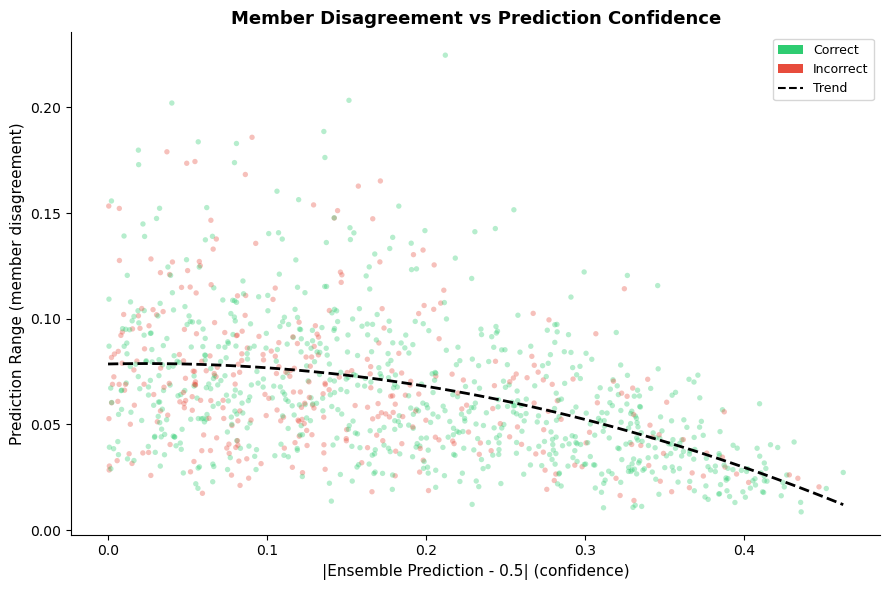

Correlation matrix:
            pred_range  abs_edge  correct
pred_range      1.0000   -0.4219  -0.0716
abs_edge       -0.4219    1.0000   0.2027
correct        -0.0716    0.2027   1.0000


In [36]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = np.where(all_df["correct"] == 1, "#2ecc71", "#e74c3c")
ax.scatter(all_df["abs_edge"], all_df["pred_range"], c=colors, alpha=0.35, s=15, edgecolors="none")

# Add trend line
from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(all_df["abs_edge"], all_df["pred_range"], 2)
x_fit = np.linspace(0, all_df["abs_edge"].max(), 100)
y_fit = coeffs[0] + coeffs[1] * x_fit + coeffs[2] * x_fit**2
ax.plot(x_fit, y_fit, "k--", linewidth=2, label="Quadratic trend")

# Legend patches
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#2ecc71", label="Correct"),
    Patch(facecolor="#e74c3c", label="Incorrect"),
    plt.Line2D([0], [0], color="k", linestyle="--", label="Trend"),
], fontsize=9)

ax.set_xlabel("|Ensemble Prediction - 0.5| (confidence)", fontsize=11)
ax.set_ylabel("Prediction Range (member disagreement)", fontsize=11)
ax.set_title("Member Disagreement vs Prediction Confidence", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "range_vs_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

corr = all_df[["pred_range", "abs_edge", "correct"]].corr()
print("Correlation matrix:")
print(corr.round(4))

### Graph 4 â€” OOF Log Loss Bar Chart: Single vs Ensemble

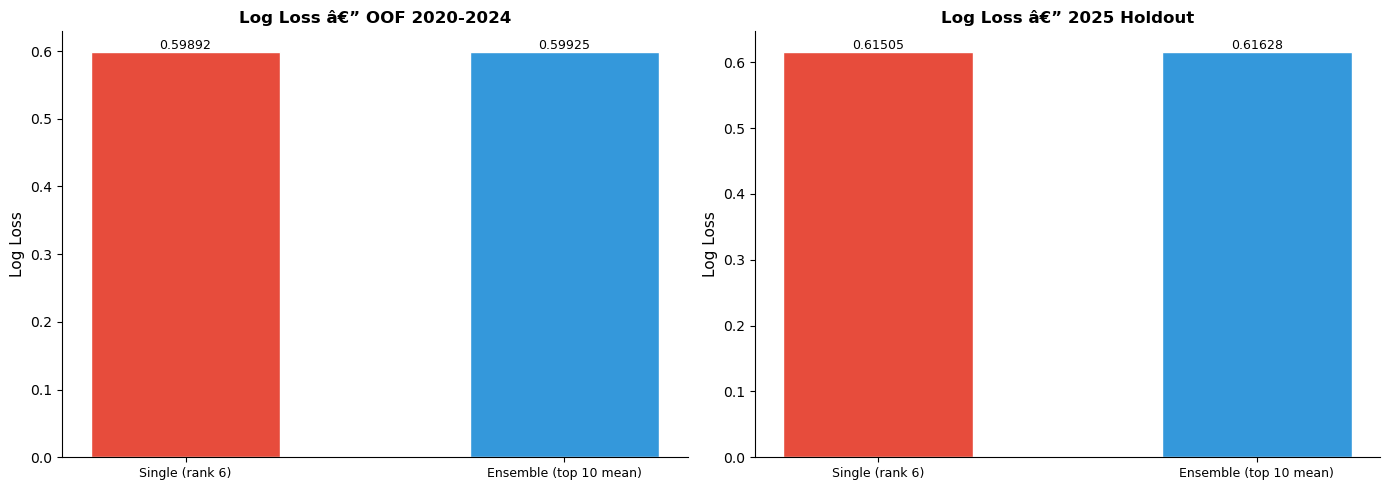

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (summary, title) in zip(axes, [(oof_summary, "OOF 2020-2024"), (holdout_summary, "2025 Holdout")]):
    models = summary["model"].values
    lls = summary["log_loss"].values
    colors = ["#e74c3c", "#3498db"]
    bars = ax.bar(range(len(models)), lls, color=colors, edgecolor="white", width=0.5)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=9)
    ax.set_ylabel("Log Loss", fontsize=11)
    ax.set_title(f"Log Loss â€” {title}", fontsize=12, fontweight="bold")
    for bar, val in zip(bars, lls):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.5f}", ha="center", va="bottom", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "single_vs_ensemble_logloss.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 5 â€” Per-Fold Log Loss: Single vs Ensemble

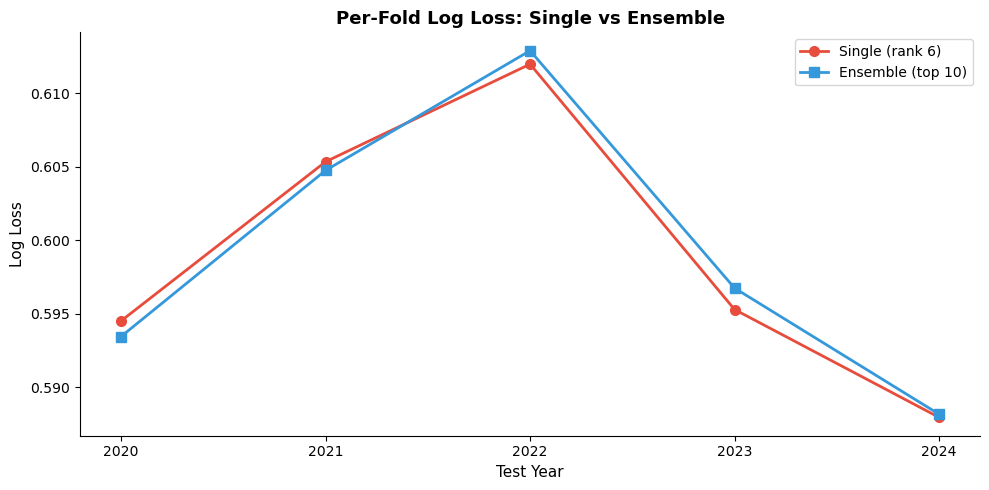

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

single_lls, ens_lls = [], []
for y in OOF_YEARS:
    sub = oof_df[oof_df["season"] == y]
    yv = sub["home_win"].values
    single_lls.append(log_loss(yv, clip(sub["single_pred"].values)))
    ens_lls.append(log_loss(yv, clip(sub["ensemble_pred"].values)))

ax.plot(OOF_YEARS, single_lls, marker="o", linewidth=2, markersize=7, color="#e74c3c", label="Single (rank 2)")
ax.plot(OOF_YEARS, ens_lls, marker="s", linewidth=2, markersize=7, color="#3498db", label="Ensemble (top 10)")

ax.set_xlabel("Test Year", fontsize=11)
ax.set_ylabel("Log Loss", fontsize=11)
ax.set_title("Per-Fold Log Loss: Single vs Ensemble", fontsize=13, fontweight="bold")
ax.set_xticks(OOF_YEARS)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "per_fold_single_vs_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

### Table 4 â€” Individual Member Performance (OOF Pooled)

How does each of the 10 configs perform individually?

In [39]:
member_rows = []
y_oof_all = oof_df["home_win"].values
for k in range(10):
    col = f"member_{k+1}_pred"
    m = compute_metrics(y_oof_all, oof_df[col].values)
    cfg = TOP_10_CONFIGS[k]
    m["member"] = k + 1
    m["depth"] = cfg["max_depth"]
    m["mcw"] = cfg["min_child_weight"]
    m["gamma"] = cfg["gamma"]
    m["rl"] = cfg["reg_lambda"]
    m["lr"] = cfg["learning_rate"]
    member_rows.append(m)

# Add ensemble row
m = compute_metrics(y_oof_all, oof_df["ensemble_pred"].values)
m["member"] = "ENS"
m["depth"] = "-"
m["mcw"] = "-"
m["gamma"] = "-"
m["rl"] = "-"
m["lr"] = "-"
member_rows.append(m)

member_df = pd.DataFrame(member_rows)[["member", "depth", "mcw", "gamma", "rl", "lr", "log_loss", "brier", "accuracy"]]
member_df

,member,depth,mcw,gamma,rl,lr,log_loss,brier,accuracy
0,1,6,3,1.0,1.0,0.03,0.601969,0.206753,0.684870
1,2,6,3,0.1,1.0,0.02,0.599394,0.205496,0.694718
2,3,6,3,0.1,0.5,0.01,0.599433,0.205653,0.686661
3,4,8,3,0.1,1.0,0.02,0.602168,0.206620,0.686661
4,5,7,3,0.5,1.0,0.02,0.600413,0.205945,0.684870
5,6,6,3,1.0,1.0,0.02,0.598917,0.205251,0.684870
6,7,8,3,0.0,2.0,0.02,0.602379,0.207245,0.683975
7,8,6,3,0.0,1.0,0.02,0.599186,0.205448,0.693823
8,9,6,2,0.1,0.5,0.03,0.600203,0.206421,0.688451
9,10,6,2,1.0,1.0,0.03,0.599815,0.206156,0.682184


## Section 5 — Std Dev as a Confidence Signal (OOF 2020–2024)

Std dev uses all 10 member predictions; unlike range (max−min) it is less sensitive to a single outlier member.

All analysis uses **OOF predictions only**.

**Questions:**
1. How is per-game std dev distributed?
2. Does lower std dev → higher accuracy / lower log loss?
3. How does std dev correlate with ensemble confidence (|p − 0.5|)?
4. Does std dev add signal beyond what |p − 0.5| already captures?


In [40]:
# 5.1  Compute per-game std dev
member_cols = [f'member_{k+1}_pred' for k in range(10)]
all_df['pred_std'] = all_df[member_cols].std(axis=1, ddof=1)

print('=== Std Dev distribution ===')
print(all_df['pred_std'].describe().round(5))
print(f"Corr(std, range):   {all_df['pred_std'].corr(all_df['pred_range']):.4f}")
print(f"Corr(std, |p-0.5|): {all_df['pred_std'].corr(all_df['abs_edge']):.4f}")


=== Std Dev distribution ===
count    1117.00000
mean        0.02063
std         0.01026
min         0.00312
25%         0.01308
50%         0.01906
75%         0.02630
max         0.06208
Name: pred_std, dtype: float64
Corr(std, range):   0.9744
Corr(std, |p-0.5|): -0.4205


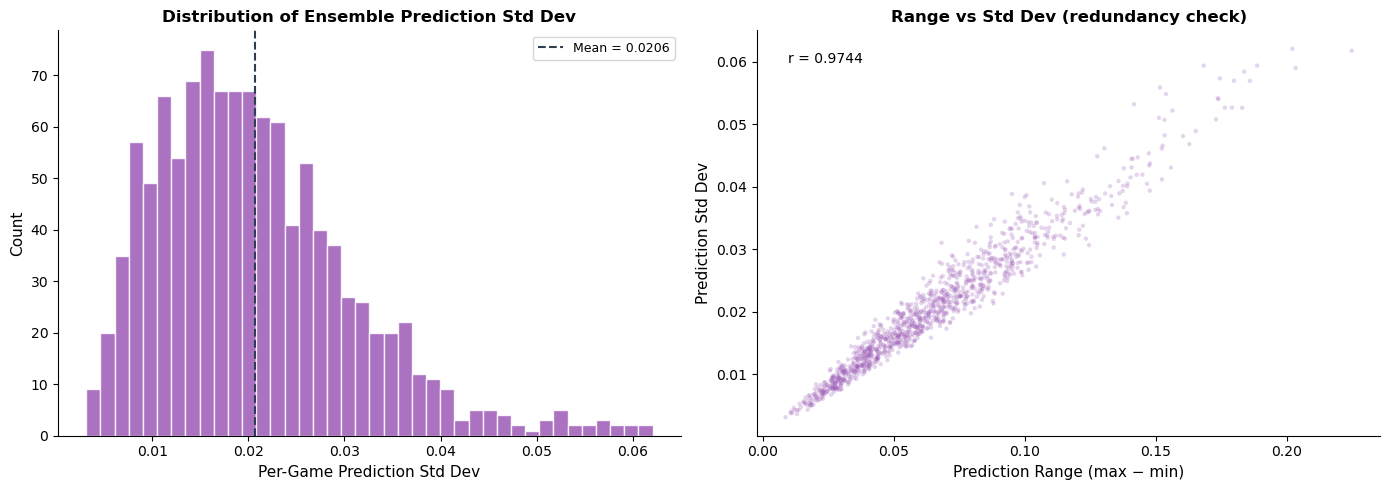

In [41]:
# 5.2  Distribution & range-vs-std scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(all_df['pred_std'], bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(all_df['pred_std'].mean(), color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f"Mean = {all_df['pred_std'].mean():.4f}")
ax.set_xlabel('Per-Game Prediction Std Dev', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Ensemble Prediction Std Dev', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.scatter(all_df['pred_range'], all_df['pred_std'], alpha=0.25, s=10,
           color='#9b59b6', edgecolors='none')
ax.set_xlabel('Prediction Range (max − min)', fontsize=11)
ax.set_ylabel('Prediction Std Dev', fontsize=11)
ax.set_title('Range vs Std Dev (redundancy check)', fontsize=12, fontweight='bold')
corr_rs = all_df['pred_range'].corr(all_df['pred_std'])
ax.text(0.05, 0.92, f'r = {corr_rs:.4f}', transform=ax.transAxes, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / 'pred_std_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Graph — Accuracy & Log Loss by Std Dev Quintile

Bin games into quintiles by per-game std dev. Q1 = most agreement (low std), Q5 = most disagreement.

 quintile  n_games  mean_std  ens_accuracy  single_accuracy  ens_log_loss  single_log_loss
        1      224    0.0086        0.7589           0.7634        0.5317           0.5320
        2      223    0.0143        0.7220           0.7085        0.5752           0.5746
        3      223    0.0191        0.6547           0.6547        0.6161           0.6188
        4      223    0.0247        0.6457           0.6323        0.6388           0.6380
        5      224    0.0364        0.6696           0.6652        0.6346           0.6313


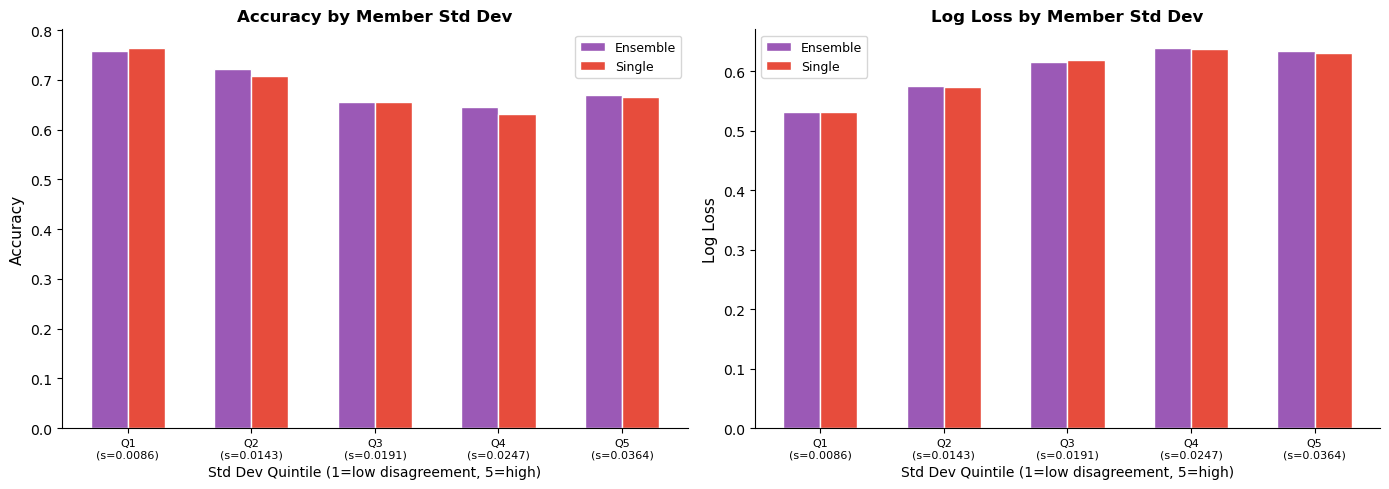

In [42]:
# 5.3  Performance by std dev quintile
all_df['std_quintile'] = pd.qcut(all_df['pred_std'], q=5, labels=False, duplicates='drop') + 1

std_q_rows = []
for q in sorted(all_df['std_quintile'].dropna().unique()):
    sub = all_df[all_df['std_quintile'] == q]
    y = sub['home_win'].values
    std_q_rows.append({
        'quintile': int(q),
        'n_games': len(sub),
        'mean_std': sub['pred_std'].mean(),
        'ens_accuracy': sub['correct'].mean(),
        'single_accuracy': sub['single_correct'].mean(),
        'ens_log_loss': log_loss(y, clip(sub['ensemble_pred'].values)),
        'single_log_loss': log_loss(y, clip(sub['single_pred'].values)),
    })

std_q_df = pd.DataFrame(std_q_rows)
print(std_q_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = std_q_df['quintile']

ax = axes[0]
ax.bar(x - 0.15, std_q_df['ens_accuracy'], width=0.3, color='#9b59b6',
       label='Ensemble', edgecolor='white')
ax.bar(x + 0.15, std_q_df['single_accuracy'], width=0.3, color='#e74c3c',
       label='Single', edgecolor='white')
ax.set_xlabel('Std Dev Quintile (1=low disagreement, 5=high)', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy by Member Std Dev', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'Q{int(q)}\n(s={r:.4f})' for q, r in zip(std_q_df['quintile'], std_q_df['mean_std'])],
    fontsize=8)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.bar(x - 0.15, std_q_df['ens_log_loss'], width=0.3, color='#9b59b6',
       label='Ensemble', edgecolor='white')
ax.bar(x + 0.15, std_q_df['single_log_loss'], width=0.3, color='#e74c3c',
       label='Single', edgecolor='white')
ax.set_xlabel('Std Dev Quintile (1=low disagreement, 5=high)', fontsize=10)
ax.set_ylabel('Log Loss', fontsize=11)
ax.set_title('Log Loss by Member Std Dev', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'Q{int(q)}\n(s={r:.4f})' for q, r in zip(std_q_df['quintile'], std_q_df['mean_std'])],
    fontsize=8)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / 'performance_by_std_quintile.png', dpi=150, bbox_inches='tight')
plt.show()


### Graph — Std Dev vs Confidence, coloured by correctness

Does the ensemble disagree more on games where it is also less confident?
Green = prediction correct, Red = incorrect. Dashed line = binned mean.

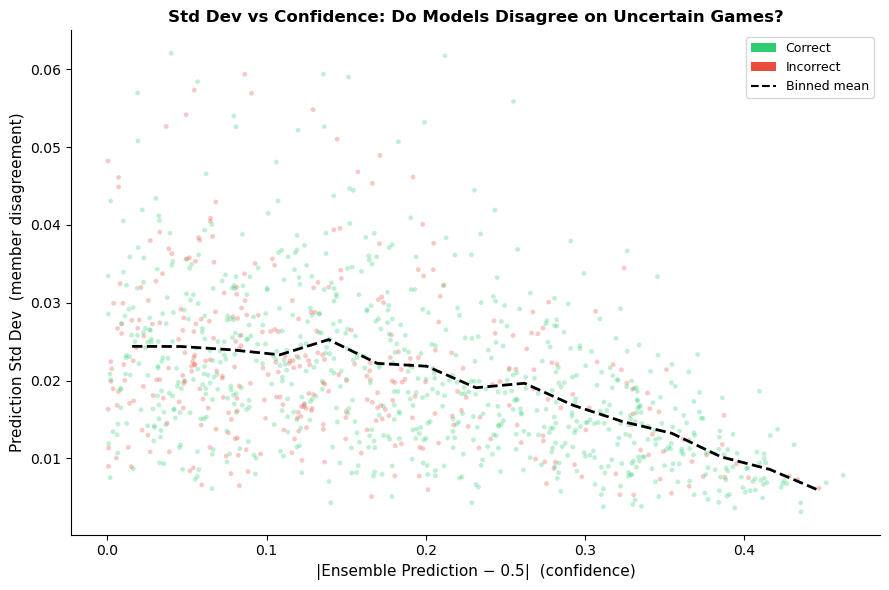

In [43]:
# 5.4  Scatter: std dev vs |p - 0.5|, coloured by correctness
fig, ax = plt.subplots(figsize=(9, 6))
point_colors = np.where(all_df['correct'] == 1, '#2ecc71', '#e74c3c')
ax.scatter(all_df['abs_edge'], all_df['pred_std'],
           c=point_colors, alpha=0.3, s=12, edgecolors='none')

# Binned mean trend
bins = pd.cut(all_df['abs_edge'], bins=15)
binned = all_df.groupby(bins, observed=True)['pred_std'].mean().reset_index()
bin_centers = binned['abs_edge'].apply(lambda iv: iv.mid).astype(float)
ax.plot(bin_centers, binned['pred_std'], 'k--', linewidth=2, label='Binned mean')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='Correct'),
    Patch(facecolor='#e74c3c', label='Incorrect'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Binned mean'),
], fontsize=9)
ax.set_xlabel('|Ensemble Prediction − 0.5|  (confidence)', fontsize=11)
ax.set_ylabel('Prediction Std Dev  (member disagreement)', fontsize=11)
ax.set_title('Std Dev vs Confidence: Do Models Disagree on Uncertain Games?',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'std_vs_confidence.png', dpi=150, bbox_inches='tight')
plt.show()


### Does Std Dev Predict Correctness Beyond Confidence?

If std dev and |p − 0.5| are tightly correlated, std dev adds little independent signal.
A logistic regression on correctness with and without std dev shows whether it explains
additional variance.

In [44]:
# 5.5  Partial-correlation / incremental logistic regression
from sklearn.linear_model import LogisticRegression as LR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss as sk_logloss

# Full pairwise correlations
corr_df = all_df[['pred_std', 'abs_edge', 'correct']].corr().round(4)
print('Pairwise correlations:')
print(corr_df)

# Incremental logistic regression: does pred_std improve correctness prediction?
scaler = StandardScaler()
y_corr = all_df['correct'].values

X1 = scaler.fit_transform(all_df[['abs_edge']])
X2 = scaler.fit_transform(all_df[['abs_edge', 'pred_std']])

lr1 = LR(max_iter=500).fit(X1, y_corr)
lr2 = LR(max_iter=500).fit(X2, y_corr)

ll1 = sk_logloss(y_corr, lr1.predict_proba(X1)[:, 1])
ll2 = sk_logloss(y_corr, lr2.predict_proba(X2)[:, 1])

print(f'\nLog-loss predicting game-level correctness:')
print(f'  |p-0.5| only:          {ll1:.5f}')
print(f'  |p-0.5| + pred_std:    {ll2:.5f}  (delta = {ll2 - ll1:+.5f})')
print(f'\nStd dev coefficient (standardised): {lr2.coef_[0][1]:.4f}')
print('Interpretation: negative = higher std dev -> less likely correct')

# Point-biserial correlation: std vs correctness
from scipy.stats import pointbiserialr
r_std, p_std   = pointbiserialr(all_df['correct'], -all_df['pred_std'])
r_edge, p_edge = pointbiserialr(all_df['correct'],  all_df['abs_edge'])
print(f'\nPoint-biserial r with correctness:')
print(f'  -pred_std:  r={r_std:.4f}  p={p_std:.4f}')
print(f'   abs_edge:  r={r_edge:.4f}  p={p_edge:.4f}')


Pairwise correlations:
          pred_std  abs_edge  correct
pred_std    1.0000   -0.4205  -0.0713
abs_edge   -0.4205    1.0000   0.2027
correct    -0.0713    0.2027   1.0000

Log-loss predicting game-level correctness:
  |p-0.5| only:          0.59761
  |p-0.5| + pred_std:    0.59754  (delta = -0.00007)

Std dev coefficient (standardised): 0.0279
Interpretation: negative = higher std dev -> less likely correct

Point-biserial r with correctness:
  -pred_std:  r=0.0713  p=0.0172
   abs_edge:  r=0.2027  p=0.0000


## Section 6 â€” Summary

**Key findings from the ensemble comparison will be populated after execution.**

Questions this notebook answers:
1. Does averaging 10 diverse hyperparameter configs outperform the single stability-chosen model?
2. How much do the 10 members typically disagree (prediction range)?
3. Is member disagreement predictive of prediction difficulty? (i.e., do high-range games have worse accuracy?)
4. Could prediction range serve as a confidence signal for the trading layer?